<a href="https://colab.research.google.com/github/lorenabao/Basics-Python/blob/main/Cat_and_Dog_Detection_Image_Classification_con_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install imgaug

In [ ]:
#!pip install -q "numpy==1.26.4" "imgaug==0.4.0"
#import os, sys
#os.kill(os.getpid(), 9)  # reinicia el runtime de Colab

In [25]:
from google.colab import files
uploaded = files.upload()   # Seleccionas el .zip

Saving cats_and_dogs.zip to cats_and_dogs.zip


In [26]:
import zipfile
import os

with zipfile.ZipFile("cats_and_dogs.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

# Ahora la tienes en /content/cats_and_dogs


In [76]:
from keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.losses import BinaryCrossentropy
from keras.metrics import BinaryAccuracy
from keras.optimizers import Adam
from keras.metrics import AUC

from keras.utils import PyDataset

import imgaug.augmenters as iaa

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os

import cv2

In [35]:
IMG_DIR = "./cats_and_dogs/"
CATS_DIR = os.path.join(IMG_DIR, "cats")
DOGS_DIR = os.path.join(IMG_DIR, "dogs")

In [28]:
IMG_SIZE = 96
SIZE = 64
CHANNELS = 3
BATCH_SIZE = 64
NUM_KEYPOINTS = 4

In [41]:
train_seq = iaa.Sequential([
    iaa.Crop(px=(0,3)), # Recorta aleatoreamente entre 0 y 3 pixeles de cada lado de la imágen,
    iaa.Fliplr(0.5), # 50% de probabilidad de voltear horizontalmente la imagen
    iaa.Sometimes(
        0.3, # 30% de probabilidad de aplicar un blur gausiano
        iaa.GaussianBlur(sigma=(0.0, 2.0)), # Aplica un blur gausiano entre 0 y 2 sigmas aleatoreamente
    ),
    iaa.Sometimes(
        0.4, # 40% de probabilidad de rotar la imagen
        iaa.Rotate(rotate=(-40,40)) # Rota entre -20 y 20 grados aleatoreamente
    ),
    iaa.Resize(size=(SIZE, SIZE)), # Aplica mismo tamaño (SIZE x SIZE) a todas las imágenes
])

test_seq = iaa.Sequential([
    iaa.Resize(size=(SIZE, SIZE)), # Para los datos de test, no queremos hacer aumentado, así que solo reedimensionamos
])

In [52]:
def list_image_paths():
    cats = [os.path.join(CATS_DIR, f) for f in os.listdir(CATS_DIR)]
    dogs = [os.path.join(DOGS_DIR, f) for f in os.listdir(DOGS_DIR)]
    return cats + dogs


Original: (375, 499, 3)  | Train: (64, 64, 3)  | Test: (64, 64, 3)


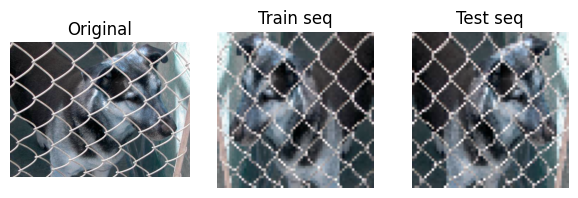

In [58]:
img_path = list_image_paths()
img = cv2.imread(img_path[3597])

img_train = train_seq(image=img)   # entrenamiento (aug + resize)
img_test  = test_seq(image=img)    # test (solo resize)

print("Original:", img.shape, " | Train:", img_train.shape, " | Test:", img_test.shape)

plt.figure(figsize=(6,2))
plt.subplot(1,3,1); plt.imshow(img);       plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(img_train); plt.title("Train seq"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(img_test);  plt.title("Test seq");  plt.axis("off")
plt.tight_layout(); plt.show()

In [69]:
class CatDogDataset(PyDataset):

    def __init__(self, image_paths, aug, batch_size=BATCH_SIZE, train=True, **kwargs):
        super().__init__(**kwargs)
        self.image_paths = image_paths
        self.aug = aug  # pipeline de data augmentation (train_seq o test_seq)
        self.batch_size = batch_size
        self.train = train
        self.on_epoch_end()

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_paths))
        if self.train:
            np.random.shuffle(self.indexes)  # orden aleatorio cada epoch

    def __getitem__(self, index):
        # índices del batch
        indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        # paths del batch
        image_paths_temp = [self.image_paths[k] for k in indexes]
        # generar y devolver batch
        images, labels = self.__data_generation(image_paths_temp)
        return images, labels

    def __data_generation(self, image_paths_temp):
        # Batches vacíos
        batch_images = np.empty(shape=(self.batch_size, SIZE, SIZE, CHANNELS), dtype="int")
        batch_labels = np.empty(shape=(self.batch_size,), dtype="float32")

        # Llenar batch con imágenes aumentadas y sus labels
        for i, path in enumerate(image_paths_temp):
            # 1) Leer imagen (BGR por OpenCV)
            img = cv2.imread(path)

            # 2) Augment/resize
            img_out = self.aug(image=img)
            batch_images[i] = img_out

            # 3) Label sencillo por texto en la ruta
            p = path.lower()
            if "cats" in p:
                label = 0.0
            else:
                label = 1.0
            batch_labels[i] = label

        # Escalado de imágenes
        batch_images = batch_images.astype("float32") / 255.0
        # Si prefieres shape (batch,1): descomenta la siguiente línea
        # batch_labels = batch_labels.reshape(-1, 1)

        return batch_images, batch_labels


In [72]:
np.random.shuffle(img_path)

split = int(0.8 * len(img_path))
img_train, img_test = img_path[:split], img_path[split:]

print(f"img_train: {len(img_train)} imágenes")
print(f"img_test: {len(img_test)} imágenes")

img_train: 3200 imágenes
img_test: 800 imágenes


In [73]:
train_dataset = CatDogDataset(img_train, aug=train_seq, batch_size=BATCH_SIZE, train=True)
test_dataset = CatDogDataset(img_test, aug=test_seq,  batch_size=BATCH_SIZE, train=False)


print(f"Total batches in training set: {len(train_dataset)}")
print(f"Total batches in validation set: {len(test_dataset)}")

Total batches in training set: 50
Total batches in validation set: 12


In [74]:
model = Sequential()

# Entrada: imágenes a color tamaño IMG_SIZE
model.add(Input(shape=(SIZE, SIZE, 3)))

# Bloque conv 1
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Bloque conv 2
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Aplanamos y pasamos a densas
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dense(128, activation="relu"))

# Capa de salida binaria
model.add(Dense(1, activation="sigmoid"))

# Compilación
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     7,930,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,982,529 (30.45 MB)

 Trainable params: 7,982,529 (30.45 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),          # optimizador recomendado
    loss=BinaryCrossentropy(),                   # porque es un problema binario
    metrics=[BinaryAccuracy(name="acc"), AUC(name="auc")]  # métricas de interés
)